In [22]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sn
from colorama import Fore
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import joblib

In [2]:
df = pd.read_csv(r'archive/train_test_network.csv')

In [3]:
df.replace('-', 0, inplace=True)

In [4]:
df.head().isnull().sum().sum()

np.int64(0)

In [5]:
df.drop(['src_ip', 'dst_ip', 'type'], axis=1, inplace=True)

In [6]:
df.head(3)

,src_port,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,...,http_request_body_len,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label
0,4444,49178,tcp,0,290.371539,101568,2592,OTH,0,108,...,0,0,0,0,0,0,0,0,0,1
1,49180,8080,tcp,0,0.000102,0,0,REJ,0,1,...,0,0,0,0,0,0,0,0,0,1
2,49180,8080,tcp,0,0.000148,0,0,REJ,0,1,...,0,0,0,0,0,0,0,0,0,1


In [7]:
le = LabelEncoder()

In [8]:
categorical_cols = ['proto', 'service', 'conn_state']

In [9]:
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [10]:
df = df.apply(pd.to_numeric, errors='coerce').fillna(0)

In [11]:
print(f'{Fore.GREEN}Preprocessing complete. Data is now all numeric.')

Preprocessing complete. Data is now all numeric.


In [12]:
cols = df.columns

In [13]:
X = df.drop('label', axis=1)
y = df['label']

In [14]:
fs_model = RandomForestClassifier(n_estimators=50)
fs_model.fit(X, y)

RandomForestClassifier(n_estimators=50)

In [15]:
feat_importances = pd.Series(fs_model.feature_importances_, index=X.columns)
top_10_features = feat_importances.nlargest(10).index.tolist()
print(f'{Fore.BLUE}Selected Features for the Model: {Fore.GREEN}{top_10_features}')

Selected Features for the Model: ['proto', 'src_pkts', 'src_ip_bytes', 'dst_port', 'dst_ip_bytes', 'src_port', 'dst_pkts', 'dns_qtype', 'dns_qclass', 'conn_state']


In [16]:
X_selected = X[top_10_features]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

In [18]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

RandomForestClassifier()

In [19]:
predictions = model.predict(X_test)
print(f'{Fore.BLUE}{classification_report(y_test, predictions)}')

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10021
           1       1.00      1.00      1.00     32188

    accuracy                           1.00     42209
   macro avg       1.00      1.00      1.00     42209
weighted avg       1.00      1.00      1.00     42209



In [21]:
joblib.dump(model, 'iot_model.pkl')

joblib.dump(top_10_features, 'selected_features.pkl')

print(f'{Fore.GREEN}Files saved!')

Files saved!


In [23]:
sn.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

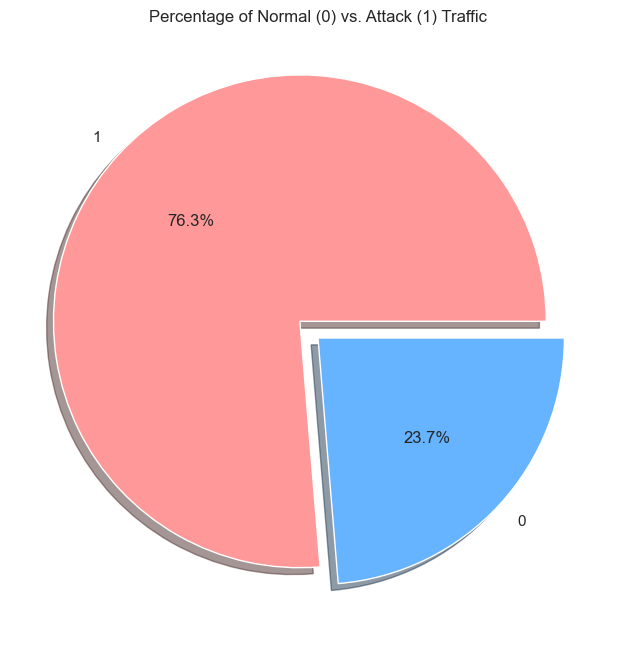

In [27]:
plt.figure(figsize=(8, 8))
df['label'].value_counts().plot.pie(explode=[0.1, 0], autopct='%1.1f%%', shadow=True, colors=['#ff9999','#66b3ff'])
plt.title('Percentage of Normal (0) vs. Attack (1) Traffic')
plt.ylabel("")
plt.show()

C:\Users\aqeel\AppData\Local\Temp\ipykernel_6572\678283758.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn.countplot(data=df_visual, x='type', palette='viridis',


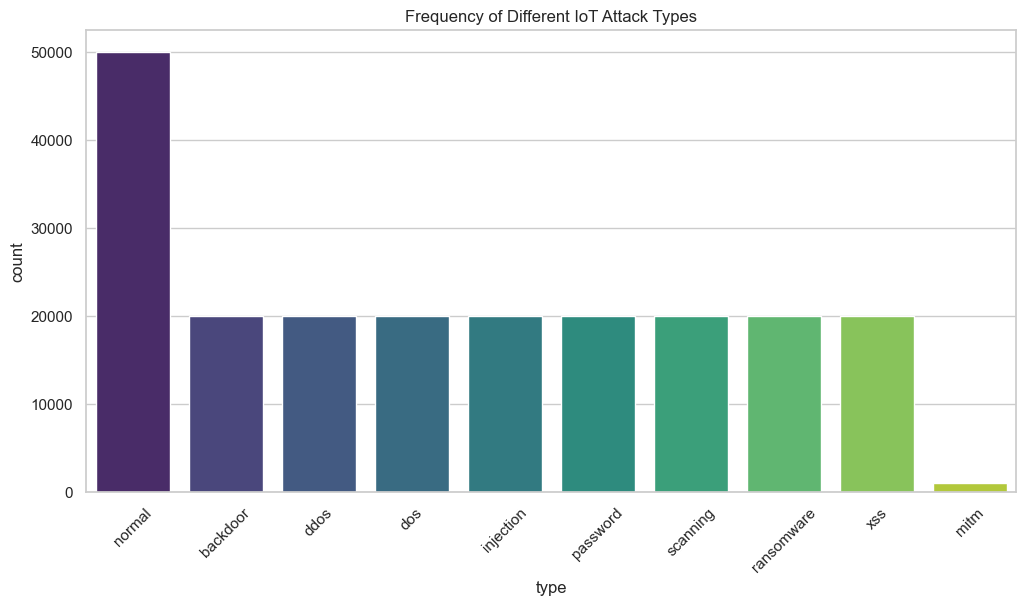

In [36]:
df_visual = pd.read_csv('archive/train_test_network.csv') 

# 2. Basic cleaning just for the graph
df_visual['type'] = df_visual['type'].replace('-', 'normal')

# 3. Now run the plot using the new 'df_visual' variable
plt.figure(figsize=(12, 6))
sn.countplot(data=df_visual, x='type', palette='viridis', 
              order = df_visual['type'].value_counts().index)
plt.title("Frequency of Different IoT Attack Types")
plt.xticks(rotation=45)
plt.show()

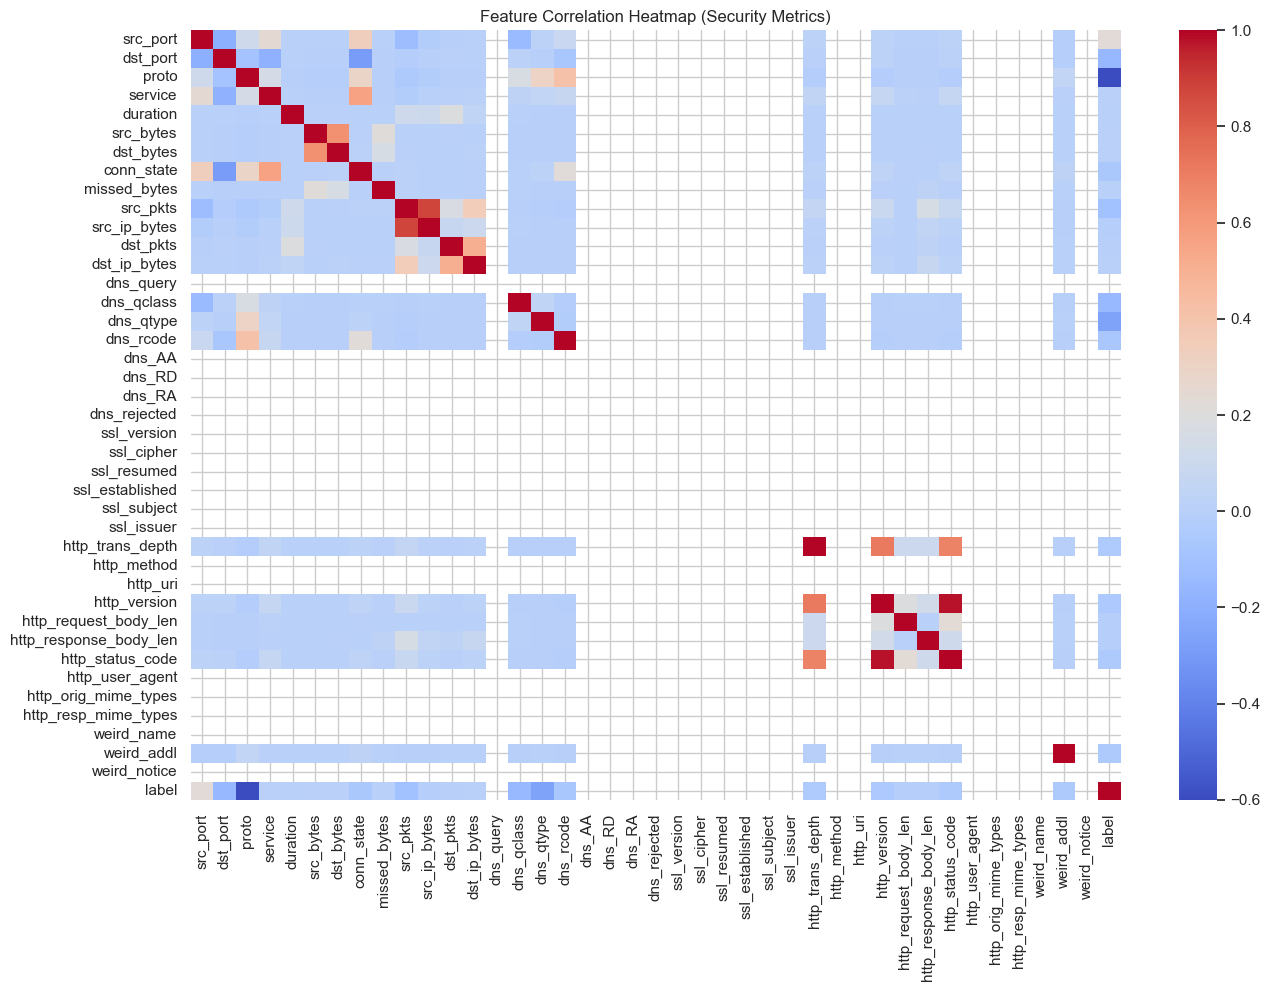

In [32]:
# Select only a subset of numeric columns for a cleaner heatmap
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(15, 10))
sn.heatmap(corr, annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap (Security Metrics)")
plt.show()

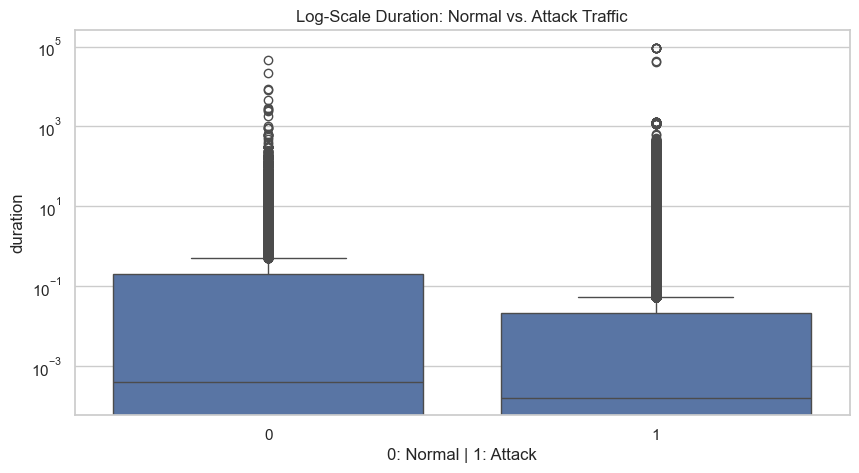

In [33]:
plt.figure(figsize=(10, 5))
sn.boxplot(x='label', y='duration', data=df)
plt.yscale('log') # Network duration varies wildly, so we use a log scale
plt.title("Log-Scale Duration: Normal vs. Attack Traffic")
plt.xlabel("0: Normal | 1: Attack")
plt.show()

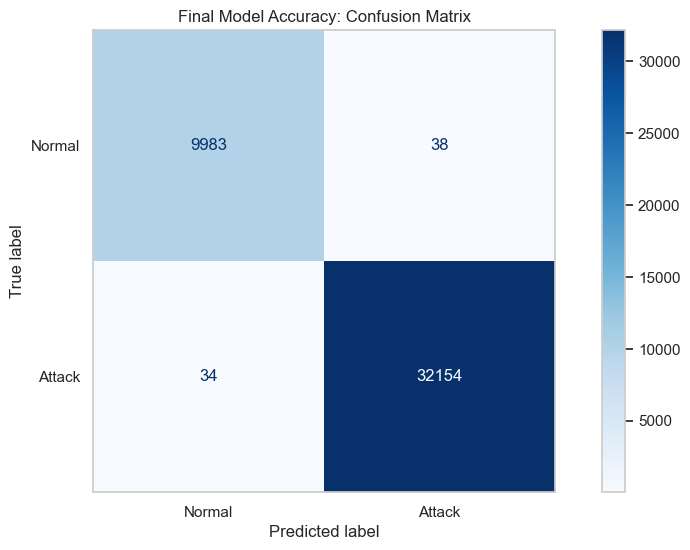

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the matrix
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])

# Plot
disp.plot(cmap='Blues')
plt.title("Final Model Accuracy: Confusion Matrix")
plt.grid(False)
plt.show()